In [1]:
# Manuscript Figure 5+6 / Supp Figure 6+7 -------------------------------------
#------------------------------------------------------------------------------

library(Seurat)
#library(SeuratDisk)
library(AUCell)
library(readxl)
library(patchwork)
library(dplyr)
library(data.table)
library(ggplot2)
library(reshape2)
library(GSEABase)
library(broom)
library(ggrepel)
library(gridExtra) # Or use the `patchwork` package for flexibility
library(ComplexHeatmap)
library(circlize)

proj_dir = '/Aging/'

### directories
data_dir = '/singleCell/Ruzicka_snRNA_Seq/data/'
data_dir2 = '/Aging/Data/Ruzicka_snRNA_Seq/'
out_dir2 = '/Aging/Aging_Clock/Output/'

PLOTDIR <- '/Aging/Aging_Clock/Plots/'
setwd(PLOTDIR)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following object is masked from ‘package:base’:

    intersect



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last



Attaching package: ‘reshape2’


The following objects are masked from ‘package:data.table’:

    dcast, melt


Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following object is masked from ‘package:SeuratObject’:

    intersect


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:



In [ ]:
# START HERE ------------------------------------------------------------------------------
# DOWNSTREAM ANALYSIS AFTER AUCELL

metadata <- read.csv(paste0(data_dir2,"Ruzicka_metadata_AUCell_all_scores.csv"))

In [ ]:
# CORRELATION / ASSOCIATION 

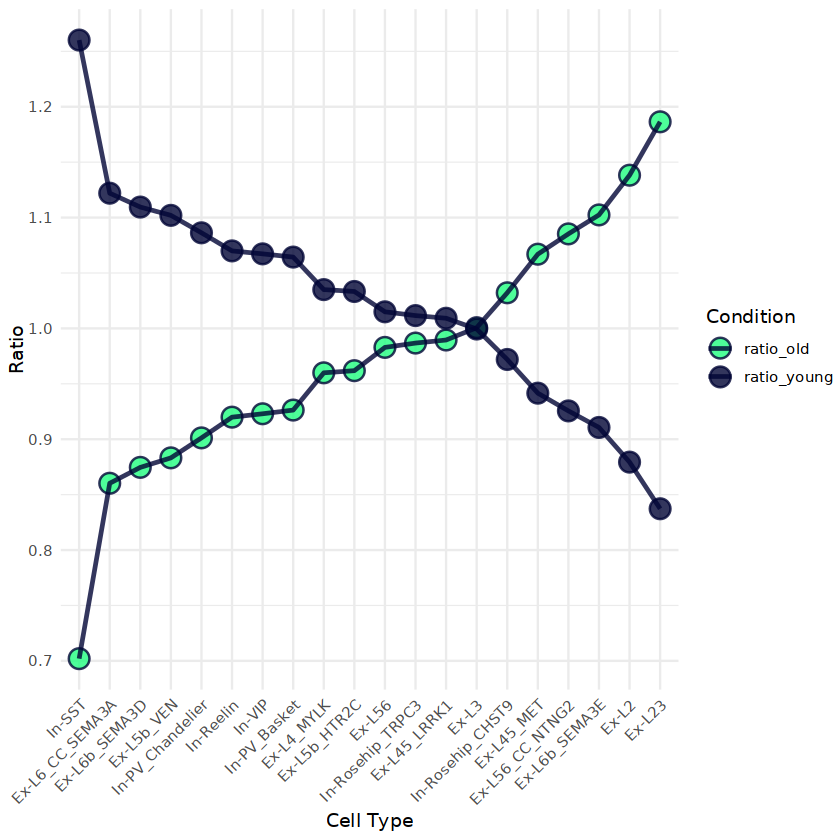

In [7]:
## Ratio vs Geneset Mean Score / Cell type

# Celltype Composition 
# Old
metadata_old <- metadata[metadata['age_status'] == 'old',]
tbl_old <- as.data.frame(table(unclass(metadata_old$Celltype)))
# Renaming columns to differentiate AD
tbl1 <- tbl_old
colnames(tbl1)[2:ncol(tbl1)] <- paste0(colnames(tbl1)[2:ncol(tbl1)], '_Old')
# Young
metadata_young <- metadata[metadata['age_status'] == 'young',]
tbl_young <- as.data.frame(table(unclass(metadata_young$Celltype)))
# Renaming columns to differentiate non-AD
tbl2 <- tbl_young
colnames(tbl2)[2:ncol(tbl2)] <- paste0(colnames(tbl2)[2:ncol(tbl2)], '_Young')
# Left join AD and non-AD tables by Var1
tbl <- left_join(tbl1, tbl2, by = 'Var1')

status <- c('Old','Young')
celltypes <- tbl['Var1'][[1]]

df1 <- data.frame()
for(s in 1:length(status)) {
    m_plus_n = sum(tbl$Freq_Old,tbl$Freq_Young)
    k = sum(tbl[paste0('Freq_',status[s])])
    df2 <- data.frame()
    for(c in 1:length(celltypes)) {
        m = tbl[tbl$Var1==celltypes[c],][['Freq_Old']] + tbl[tbl$Var1==celltypes[c],][['Freq_Young']]
        q = tbl[tbl$Var1==celltypes[c],][[paste0('Freq_',status[s])]] 
        df3 = data.frame(m_plus_n, m, k, q)
        df3$celltype = celltypes[c]
        
        if (c > 1) df2 = rbind(df2,df3)
        if (c == 1) df2 = df3  
                }
    colnames(df2)[c(1:4)] = paste0(colnames(df2)[c(1:4)],"_",status[s])
    if (s > 1) df1 = left_join(df1,df2, by = 'celltype')
    if (s == 1) df1 = df2
    }
rownames(df1) <- df1$celltype
# Ratio = proportion of celltype in group relative to its proprtion in total population 
# High = more prevalent in group 
# Low = less prevalent in total population 
df1$ratio_old <- (df1$q_Old/df1$k_Old)/(df1$m_Old/df1$m_plus_n_Old)
df1$ratio_young <- (df1$q_Young/df1$k_Young)/(df1$m_Young/df1$m_plus_n_Young)
df1 <- df1[,10:11]
df1$Celltype <- rownames(df1)
df1 <- df1[-which(df1$Celltype=='Ex-NRGN'),]

# Reorder celltype based on ratio_PD
df1_long <- reshape2::melt(df1, id.vars = "Celltype", 
                           variable.name = "Condition", 
                           value.name = "Ratio")               
df1_long$Celltype <- factor(df1_long$Celltype, 
                            levels = df1$Celltype[order(df1$ratio_old)])

#pdf(paste0(PLOTDIR, 'Scatterplot.Ruzicka_celltype_composition_ratio.pdf'), width = 5, height = 5)              
ggplot(df1_long, aes(x = Celltype, y = Ratio, color = Condition, group = Condition, fill = Condition)) +
  geom_point(size = 5, alpha = 0.8, shape = 21, stroke = 0.8) +  # Add points with fill and outline
  geom_line(size = 1, alpha = 0.8) +  # Connect the dots with lines
  scale_color_manual(values = rep('#000435',3)) +  # Set colors for outline
  scale_fill_manual(values = c("#21FE80","#000435", "#FFFFFF")) +  # Set colors for fill
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  labs(x = "Cell Type", y = "Ratio")
#dev.off()

In [11]:
# LM

result <- metadata %>%
  group_by(Celltype) %>%
  summarise(across(c(geneset_sc0,geneset_sc24,
                    geneset_dd.x, can_sen.x, sen_init.x, sen_resp.x, cellage.x), ~ mean(.x, na.rm = TRUE)))
result <- result[-which(result$Celltype=='Ex-NRGN'),]
result <- left_join(df1, result, by='Celltype')

# Subset data for young and old
tbl_young <- subset(metadata, age_status == 'young')
tbl_old <- subset(metadata, age_status == 'old')

result_young <- tbl_young %>%
  group_by(Celltype) %>%
  summarise(across(c(geneset_sc0,geneset_sc24, geneset_dd.x, can_sen.x, sen_init.x, sen_resp.x), ~ mean(.x, na.rm = TRUE)))
result_young <- result_young[-which(result_young$Celltype=='Ex-NRGN'),]
result_young <- left_join(df1, result_young, by='Celltype')

result_old <- tbl_old %>%
  group_by(Celltype) %>%
  summarise(across(c(geneset_sc0,geneset_sc24,geneset_dd.x, can_sen.x, sen_init.x, sen_resp.x), ~ mean(.x, na.rm = TRUE)))
result_old <- result_old[-which(result_old$Celltype=='Ex-NRGN'),]
result_old <- left_join(df1, result_old, by='Celltype')


##################################

# Function to create a plot for a given subset of data and model
create_plot <- function(data, x_var, y_var, title) {
  lm.out <- lm(as.formula(paste(y_var, "~", x_var)) , data = data)
  model_stats <- glance(lm.out)
  coeff_stats <- tidy(lm.out)
  print(coeff_stats)
  
  annotation_text <- paste0(
    "Coefficient: ", round(coeff_stats$estimate[2], 2), "\n", 
    "p-value: ", format.pval(coeff_stats$p.value[2], digits = 2), "\n",
    "Adj R²: ", round(model_stats$adj.r.squared, 2)
  )
  
  ggplot(data, aes_string(x = x_var, y = y_var)) +
    geom_point(shape = 21, color = "#FFFFFF", fill = "#000435", size = 5, stroke = 0.2, alpha = 0.8) +
    geom_smooth(method = "lm", color = "#21FE80", fill = "steelblue", alpha = 0.2, se = TRUE) +
    labs(title = title, y = 'Ratio' , x = x_var) +
    annotate(
      "text", 
      x = max(data[[x_var]]) - diff(range(data[[x_var]])) * 0.3, 
      y = max(data[[y_var]]) - diff(range(data[[y_var]])) * 0.1, 
      label = annotation_text, hjust = -0.2, vjust = 7, size = 2.5, color = "black"
    ) +
    geom_text_repel(aes(label = Celltype), size = 3, max.overlaps = 10) +
    coord_cartesian(clip = "off") +
    theme_minimal(base_size = 14) +
    theme(
      plot.title = element_text(hjust = 0.5, size = 16, face = "bold"),
      axis.title = element_text(size = 10),
      axis.text = element_text(size = 10)
    )
}

# Create plots
pdf(paste0(PLOTDIR, 'ggplot.Ruzicka_mean_celltype_ratio_mean_no_NRGN_geneset_score.pdf'), width = 8, height = 8)
sign <- c("geneset_sc0", "geneset_sc24",'geneset_dd.x','can_sen.x', 'sen_init.x', 'sen_resp.x', 'cellage.x')
for(i in sign){
    plot1 <- create_plot(result, i, "ratio_young", paste0('Age Range ',min(na.omit(metadata_young$Age)),'-',max(na.omit(metadata_young$Age))))
    plot2 <- create_plot(result, i, "ratio_old", paste0('Age Range ',min(na.omit(metadata_old$Age)),'-',max(na.omit(metadata_old$Age)))) 
    # Arrange all plots in a grid
    grid.arrange(plot1, plot2, nrow = 2, ncol = 2)
    }
dev.off()

# A tibble: 2 × 5
  term        estimate std.error statistic  p.value
  <chr>          <dbl>     <dbl>     <dbl>    <dbl>
1 (Intercept)    1.02     0.0251   40.8    3.49e-19
2 geneset_sc0   -0.155    2.72     -0.0570 9.55e- 1
# A tibble: 2 × 5
  term        estimate std.error statistic  p.value
  <chr>          <dbl>     <dbl>     <dbl>    <dbl>
1 (Intercept)    0.973    0.0288   33.8    9.47e-18
2 geneset_sc0    0.177    3.11      0.0570 9.55e- 1


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


# A tibble: 2 × 5
  term         estimate std.error statistic  p.value
  <chr>           <dbl>     <dbl>     <dbl>    <dbl>
1 (Intercept)      1.07    0.0226     47.3  2.46e-20
2 geneset_sc24    -4.21    1.27       -3.32 3.78e- 3
# A tibble: 2 × 5
  term         estimate std.error statistic  p.value
  <chr>           <dbl>     <dbl>     <dbl>    <dbl>
1 (Intercept)     0.919    0.0259     35.5  4.16e-18
2 geneset_sc24    4.83     1.45        3.32 3.78e- 3


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


# A tibble: 2 × 5
  term         estimate std.error statistic   p.value
  <chr>           <dbl>     <dbl>     <dbl>     <dbl>
1 (Intercept)     0.795     0.160      4.98 0.0000971
2 geneset_dd.x    6.92      4.80       1.44 0.167    
# A tibble: 2 × 5
  term         estimate std.error statistic    p.value
  <chr>           <dbl>     <dbl>     <dbl>      <dbl>
1 (Intercept)      1.24     0.183      6.76 0.00000248
2 geneset_dd.x    -7.92     5.50      -1.44 0.167     


...

# A tibble: 2 × 5
  term        estimate std.error statistic  p.value
  <chr>          <dbl>     <dbl>     <dbl>    <dbl>
1 (Intercept)    0.993    0.0387    25.6   1.29e-15
2 sen_resp.x     3.74     4.05       0.925 3.67e- 1
# A tibble: 2 × 5
  term        estimate std.error statistic  p.value
  <chr>          <dbl>     <dbl>     <dbl>    <dbl>
1 (Intercept)     1.01    0.0444    22.7   1.06e-14
2 sen_resp.x     -4.29    4.63      -0.925 3.67e- 1


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


# A tibble: 2 × 5
  term        estimate std.error statistic     p.value
  <chr>          <dbl>     <dbl>     <dbl>       <dbl>
1 (Intercept)     1.23     0.160      7.68 0.000000433
2 cellage.x      -9.05     6.96      -1.30 0.210      
# A tibble: 2 × 5
  term        estimate std.error statistic  p.value
  <chr>          <dbl>     <dbl>     <dbl>    <dbl>
1 (Intercept)    0.738     0.183      4.03 0.000783
2 cellage.x     10.4       7.97       1.30 0.210   


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


pdf 
  2

In [13]:
## Geneset Mean Score / Cell type

tbl <- metadata[,which(names(metadata) %in% c('Celltype','age_status','Age','Sex','geneset_sc0','geneset_sc24',
                                             'geneset_dd.x','can_sen.x', 'sen_init.x', 'sen_resp.x', 'cellage.x'))]

result<- tbl %>%
  group_by(Celltype) %>%
  summarise(across(c(geneset_sc0,geneset_sc24,geneset_dd.x, can_sen.x, sen_init.x, sen_resp.x, cellage.x), ~ mean(.x, na.rm = TRUE)))
result <- result[-which(result$Celltype=='Ex-NRGN'),]

##################################

# Function to create a plot for a given subset of data and model
create_plot <- function(data, x_var, y_var, title) {
  lm.out <- lm(as.formula(paste(y_var, "~", x_var)) , data = data)
  model_stats <- glance(lm.out)
  coeff_stats <- tidy(lm.out)
  print(coeff_stats)
  
  annotation_text <- paste0(
    "Coefficient: ", round(coeff_stats$estimate[2], 2), "\n", 
    "p-value: ", format.pval(coeff_stats$p.value[2], digits = 2), "\n",
    "Adj R²: ", round(model_stats$adj.r.squared, 2)
  )
  
  ggplot(data, aes_string(x = x_var, y = y_var)) +
    geom_point(shape = 21, color = "#FFFFFF", fill = "#000435", size = 5, stroke = 0.2, alpha = 0.8) +
    geom_smooth(method = "lm", color = "#21FE80", fill = "steelblue", alpha = 0.2, se = TRUE) +
    labs(title = title, y = y_var , x = "Age Signature") +
    annotate(
      "text", 
      x = max(data[[x_var]]) - diff(range(data[[x_var]])) * 0.3, 
      y = max(data[[y_var]]) - diff(range(data[[y_var]])) * 0.1, 
      label = annotation_text, hjust = -0.2, vjust = -0.2, size = 2.5, color = "black"
    ) +
    geom_text_repel(aes(label = Celltype), size = 3, max.overlaps = 10) +
    coord_cartesian(clip = "off") +
    theme_minimal(base_size = 14) +
    theme(
      plot.title = element_text(hjust = 0.5, size = 16, face = "bold"),
      axis.title = element_text(size = 10),
      axis.text = element_text(size = 10)
    )
}

# Create plots
pdf(paste0(PLOTDIR, 'ggplot.Ruzicka_mean_celltype_unsplit_no_NRGN_geneset_score.pdf'), width = 8, height = 8)
sign <- c('geneset_dd.x','can_sen.x', 'sen_init.x', 'sen_resp.x', 'cellage.x')
for(i in sign){
    plot1 <- create_plot(result, "geneset_sc0",i, paste0('Systemic')) 
    plot2 <- create_plot(result, "geneset_sc24",i, paste0('Intrinsic'))
    # Arrange all plots in a grid
    grid.arrange(plot1, plot2, nrow = 2, ncol = 2)
    }
dev.off()

# A tibble: 2 × 5
  term        estimate std.error statistic  p.value
  <chr>          <dbl>     <dbl>     <dbl>    <dbl>
1 (Intercept)   0.0328   0.00117    28.2   2.44e-16
2 geneset_sc0   0.0266   0.126       0.211 8.35e- 1
# A tibble: 2 × 5
  term         estimate std.error statistic  p.value
  <chr>           <dbl>     <dbl>     <dbl>    <dbl>
1 (Intercept)    0.0340   0.00127     26.8  5.95e-16
2 geneset_sc24  -0.0976   0.0712      -1.37 1.88e- 1


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


# A tibble: 2 × 5
  term        estimate std.error statistic  p.value
  <chr>          <dbl>     <dbl>     <dbl>    <dbl>
1 (Intercept)  0.00617  0.000477    12.9   1.51e-10
2 geneset_sc0  0.0164   0.0516       0.318 7.54e- 1
# A tibble: 2 × 5
  term         estimate std.error statistic  p.value
  <chr>           <dbl>     <dbl>     <dbl>    <dbl>
1 (Intercept)   0.00667  0.000525     12.7  1.99e-10
2 geneset_sc24 -0.0377   0.0294       -1.28 2.16e- 1


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


# A tibble: 2 × 5
  term        estimate std.error statistic  p.value
  <chr>          <dbl>     <dbl>     <dbl>    <dbl>
1 (Intercept)   0.0146  0.000523    27.8   3.03e-16
2 geneset_sc0   0.0235  0.0566       0.416 6.83e- 1
# A tibble: 2 × 5
  term         estimate std.error statistic  p.value
  <chr>           <dbl>     <dbl>     <dbl>    <dbl>
1 (Intercept)   0.0147   0.000601    24.5   2.79e-15
2 geneset_sc24 -0.00732  0.0337      -0.217 8.30e- 1


...

# A tibble: 2 × 5
  term        estimate std.error statistic    p.value
  <chr>          <dbl>     <dbl>     <dbl>      <dbl>
1 (Intercept)  0.00875   0.00137      6.39 0.00000512
2 geneset_sc0 -0.188     0.148       -1.27 0.221     
# A tibble: 2 × 5
  term         estimate std.error statistic     p.value
  <chr>           <dbl>     <dbl>     <dbl>       <dbl>
1 (Intercept)    0.0102   0.00140      7.33 0.000000829
2 geneset_sc24  -0.203    0.0782      -2.59 0.0184     


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


# A tibble: 2 × 5
  term        estimate std.error statistic  p.value
  <chr>          <dbl>     <dbl>     <dbl>    <dbl>
1 (Intercept)  0.0227   0.000813   28.0    2.75e-16
2 geneset_sc0  0.00503  0.0879      0.0572 9.55e- 1
# A tibble: 2 × 5
  term         estimate std.error statistic  p.value
  <chr>           <dbl>     <dbl>     <dbl>    <dbl>
1 (Intercept)    0.0224  0.000921    24.3   3.21e-15
2 geneset_sc24   0.0336  0.0516       0.651 5.23e- 1


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


pdf 
  2

In [14]:
# Geneset Mean Score / Cell type (split by age)

tbl <- metadata[,which(names(metadata) %in% c('Celltype','age_status','Age','Sex','geneset_sc0','geneset_sc24',
                                             'geneset_dd.x','can_sen.x', 'sen_init.x', 'sen_resp.x', 'cellage.x'))]

# Subset data for young and old
tbl_young <- subset(tbl, age_status == 'young')
tbl_old <- subset(tbl, age_status == 'old')

result_young <- tbl_young %>%
  group_by(Celltype) %>%
  summarise(across(c(geneset_sc0,geneset_sc24, geneset_dd.x, can_sen.x, sen_init.x, sen_resp.x, cellage.x), ~ mean(.x, na.rm = TRUE)))
result_young <- result_young[-which(result_young$Celltype=='Ex-NRGN'),]

result_old <- tbl_old %>%
  group_by(Celltype) %>%
  summarise(across(c(geneset_sc0,geneset_sc24,geneset_dd.x, can_sen.x, sen_init.x, sen_resp.x, cellage.x), ~ mean(.x, na.rm = TRUE)))
result_old <- result_old[-which(result_old$Celltype=='Ex-NRGN'),]

##################################



# Function to create a plot for a given subset of data and model
create_plot <- function(data, x_var, y_var, title) {
  lm.out <- lm(as.formula(paste(y_var, "~", x_var)) , data = data)
  model_stats <- glance(lm.out)
  coeff_stats <- tidy(lm.out)
  print(coeff_stats)
  
  annotation_text <- paste0(
    "Coefficient: ", round(coeff_stats$estimate[2], 2), "\n", 
    "p-value: ", format.pval(coeff_stats$p.value[2], digits = 2), "\n",
    "Adj R²: ", round(model_stats$adj.r.squared, 2)
  )
  
  ggplot(data, aes_string(x = x_var, y = y_var)) +
    geom_point(shape = 21, color = "#FFFFFF", fill = "#000435", size = 5, stroke = 0.2, alpha = 0.8) +
    geom_smooth(method = "lm", color = "#21FE80", fill = "steelblue", alpha = 0.2, se = TRUE) +
    labs(title = title, y = y_var , x = "Age Signature") +
    annotate(
      "text", 
      x = max(data[[x_var]]) - diff(range(data[[x_var]])) * 0.3, 
      y = max(data[[y_var]]) - diff(range(data[[y_var]])) * 0.1, 
      label = annotation_text, hjust = -0.2, vjust = -0.2, size = 2.5, color = "black"
    ) +
    geom_text_repel(aes(label = Celltype), size = 3, max.overlaps = 10) +
    coord_cartesian(clip = "off") +
    theme_minimal(base_size = 14) +
    theme(
      plot.title = element_text(hjust = 0.5, size = 16, face = "bold"),
      axis.title = element_text(size = 10),
      axis.text = element_text(size = 10)
    )
}

# Create plots
pdf(paste0(PLOTDIR, 'ggplot.Ruzicka_mean_celltype_no_NRGN_geneset_score.pdf'), width = 8, height = 8)
sign <- c('geneset_dd.x','can_sen.x', 'sen_init.x', 'sen_resp.x', 'cellage.x')
for(i in sign){
    plot1 <- create_plot(result_young, "geneset_sc0",i, paste0('Systemic: Young')) 
    plot2 <- create_plot(result_young, "geneset_sc24",i, paste0('Intrinsic: Young'))
    plot3 <- create_plot(result_old, "geneset_sc0",i, paste0('Systemic: Old'))
    plot4 <- create_plot(result_old, "geneset_sc24",i, paste0('Intrinsic: Old'))
    # Arrange all plots in a grid
    grid.arrange(plot1, plot2, plot3, plot4, nrow = 2, ncol = 2)
    }
dev.off()

# A tibble: 2 × 5
  term        estimate std.error statistic  p.value
  <chr>          <dbl>     <dbl>     <dbl>    <dbl>
1 (Intercept)   0.0328   0.00143     23.0  8.56e-15
2 geneset_sc0   0.150    0.123        1.22 2.38e- 1
# A tibble: 2 × 5
  term         estimate std.error statistic  p.value
  <chr>           <dbl>     <dbl>     <dbl>    <dbl>
1 (Intercept)    0.0314   0.00131    24.0   3.99e-15
2 geneset_sc24  -0.0436   0.0927     -0.470 6.44e- 1
# A tibble: 2 × 5
  term        estimate std.error statistic  p.value
  <chr>          <dbl>     <dbl>     <dbl>    <dbl>
1 (Intercept)   0.0381   0.00268    14.2   3.21e-11
2 geneset_sc0  -0.115    0.122      -0.939 3.60e- 1
# A tibble: 2 × 5
  term         estimate std.error statistic  p.value
  <chr>           <dbl>     <dbl>     <dbl>    <dbl>
1 (Intercept)    0.0410   0.00225     18.2  4.72e-13
2 geneset_sc24  -0.156    0.0603      -2.58 1.89e- 2


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


# A tibble: 2 × 5
  term        estimate std.error statistic  p.value
  <chr>          <dbl>     <dbl>     <dbl>    <dbl>
1 (Intercept)  0.00633  0.000525    12.1   4.70e-10
2 geneset_sc0  0.0255   0.0453       0.563 5.80e- 1
# A tibble: 2 × 5
  term         estimate std.error statistic  p.value
  <chr>           <dbl>     <dbl>     <dbl>    <dbl>
1 (Intercept)   0.00579  0.000439     13.2  1.09e-10
2 geneset_sc24 -0.0496   0.0312       -1.59 1.29e- 1
# A tibble: 2 × 5
  term        estimate std.error statistic    p.value
  <chr>          <dbl>     <dbl>     <dbl>      <dbl>
1 (Intercept)  0.00707   0.00108     6.55  0.00000372
2 geneset_sc0 -0.0172    0.0492     -0.349 0.731     
# A tibble: 2 × 5
  term         estimate std.error statistic     p.value
  <chr>           <dbl>     <dbl>     <dbl>       <dbl>
1 (Intercept)   0.00793  0.000990      8.01 0.000000242
2 geneset_sc24 -0.0356   0.0265       -1.34 0.197      


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


# A tibble: 2 × 5
  term        estimate std.error statistic  p.value
  <chr>          <dbl>     <dbl>     <dbl>    <dbl>
1 (Intercept)   0.0151  0.000646    23.3   6.70e-15
2 geneset_sc0   0.0446  0.0558       0.800 4.34e- 1
# A tibble: 2 × 5
  term         estimate std.error statistic  p.value
  <chr>           <dbl>     <dbl>     <dbl>    <dbl>
1 (Intercept)   0.0147   0.000582   25.3    1.57e-15
2 geneset_sc24  0.00212  0.0413      0.0513 9.60e- 1
# A tibble: 2 × 5
  term        estimate std.error statistic  p.value
  <chr>          <dbl>     <dbl>     <dbl>    <dbl>
1 (Intercept)  0.0157    0.00103    15.2   1.04e-11
2 geneset_sc0 -0.00877   0.0472     -0.186 8.55e- 1
# A tibble: 2 × 5
  term         estimate std.error statistic  p.value
  <chr>           <dbl>     <dbl>     <dbl>    <dbl>
1 (Intercept)    0.0163  0.000971    16.8   1.86e-12
2 geneset_sc24  -0.0237  0.0260      -0.908 3.76e- 1


...

# A tibble: 2 × 5
  term        estimate std.error statistic  p.value
  <chr>          <dbl>     <dbl>     <dbl>    <dbl>
1 (Intercept)  0.00703   0.00167     4.21  0.000522
2 geneset_sc0 -0.142     0.144      -0.989 0.336   
# A tibble: 2 × 5
  term         estimate std.error statistic   p.value
  <chr>           <dbl>     <dbl>     <dbl>     <dbl>
1 (Intercept)   0.00611   0.00119      5.11 0.0000726
2 geneset_sc24 -0.281     0.0848      -3.31 0.00388  
# A tibble: 2 × 5
  term        estimate std.error statistic p.value
  <chr>          <dbl>     <dbl>     <dbl>   <dbl>
1 (Intercept)   0.0103   0.00302     3.40  0.00318
2 geneset_sc0  -0.110    0.138      -0.798 0.435  
# A tibble: 2 × 5
  term         estimate std.error statistic  p.value
  <chr>           <dbl>     <dbl>     <dbl>    <dbl>
1 (Intercept)    0.0121   0.00276      4.37 0.000366
2 geneset_sc24  -0.118    0.0739      -1.60 0.128   


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“ggrepel: 1 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


# A tibble: 2 × 5
  term        estimate std.error statistic  p.value
  <chr>          <dbl>     <dbl>     <dbl>    <dbl>
1 (Intercept)  0.0227   0.000891   25.5    1.45e-15
2 geneset_sc0  0.00615  0.0769      0.0799 9.37e- 1
# A tibble: 2 × 5
  term         estimate std.error statistic  p.value
  <chr>           <dbl>     <dbl>     <dbl>    <dbl>
1 (Intercept)    0.0227  0.000787    28.9   1.53e-16
2 geneset_sc24   0.0175  0.0558       0.314 7.57e- 1
# A tibble: 2 × 5
  term        estimate std.error statistic  p.value
  <chr>          <dbl>     <dbl>     <dbl>    <dbl>
1 (Intercept)  0.0230    0.00192   12.0    5.04e-10
2 geneset_sc0  0.00328   0.0875     0.0374 9.71e- 1
# A tibble: 2 × 5
  term         estimate std.error statistic  p.value
  <chr>           <dbl>     <dbl>     <dbl>    <dbl>
1 (Intercept)    0.0222   0.00183    12.2   3.95e-10
2 geneset_sc24   0.0243   0.0490      0.495 6.26e- 1


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“ggrepel: 2 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


pdf 
  2

In [ ]:
# HYPERGEOMTRIC TEST ---------------------------------------------------------------------

In [11]:
# Overrepresentation Analysis By Status

# Aging Signatures 
# Senescence+DNA Damage Signatures

#obj@meta.data = obj@meta.data %>% mutate(age_status = case_when(Age <= 52 ~ "young",
#                                                 Age >= 69 ~ "old"))
# Calculating geneSet_pos and geneSet_neg 
tbl <- table(metadata$age_status)
pos0 <- table(metadata$age_status, metadata$geneset_pos0.y)
neg0 <- table(metadata$age_status, metadata$geneset_neg0.y)
pos24 <- table(metadata$age_status, metadata$geneset_pos24.y)
neg24 <- table(metadata$age_status, metadata$geneset_neg24.y)
can_sen <- table(metadata$age_status, metadata$can_sen.y)
sen_init <- table(metadata$age_status, metadata$sen_init.y)
sen_resp <- table(metadata$age_status, metadata$sen_resp.y)
dna_damage <- table(metadata$age_status, metadata$geneset_dd.y)

tbl <- as.data.frame(cbind(tbl, pos0, neg0, pos24, neg24, 
                           can_sen, sen_init, sen_resp, dna_damage))
tbl$Var1 <- rownames(tbl)

direction <- c('geneset_pos0', 'geneset_neg0', 'geneset_pos24', 'geneset_neg24',
              'can_sen', 'sen_init','sen_resp','geneset_dd')
status <- c('old','young')

df <- data.frame()
for(d in 1:length(direction)) {
    print(direction[d])
    df1 <- data.frame()
    for(s in 1:length(status)) {
        print(status[s])
        m_plus_n = sum(tbl$tbl)
        m = sum(tbl[paste0(direction[d])])
        k = tbl[tbl$Var1==status[s],][['tbl']]
        q = tbl[tbl$Var1==status[s],][[paste0(direction[d])]]
        phyper = phyper(q, m, m_plus_n - m, k, lower.tail = FALSE, log.p = FALSE)
        df2 = data.frame(m_plus_n, m, k, q, phyper)
        df2$status = status[s]
        
        if (s > 1) df1 = rbind(df1,df2)
        if (s == 1) df1 = df2 
                }
    df1 = df1[,c('status','phyper')]
    colnames(df1)[2] = paste0(direction[d])

    if (d > 1) df = left_join(df,df1, by = 'status')
    if (d == 1) df = df1
    }

counts <- tbl
phyper <- df
#write.csv(counts, paste0(out_dir2,'Ruzicka_status_counts.csv'))
#write.csv(phyper, paste0(out_dir2,'Ruzicka_status_phyper_uncorrected.csv'))

[1] "geneset_pos0"
[1] "old"
[1] "young"
[1] "geneset_neg0"
[1] "old"
[1] "young"
[1] "geneset_pos24"
[1] "old"
[1] "young"
[1] "geneset_neg24"
[1] "old"
[1] "young"
[1] "can_sen"
[1] "old"
[1] "young"
[1] "sen_init"
[1] "old"
[1] "young"
[1] "sen_resp"
[1] "old"
[1] "young"
[1] "geneset_dd"
[1] "old"
[1] "young"


Warning message:
“The input is a data frame-like object, convert it to a matrix.”


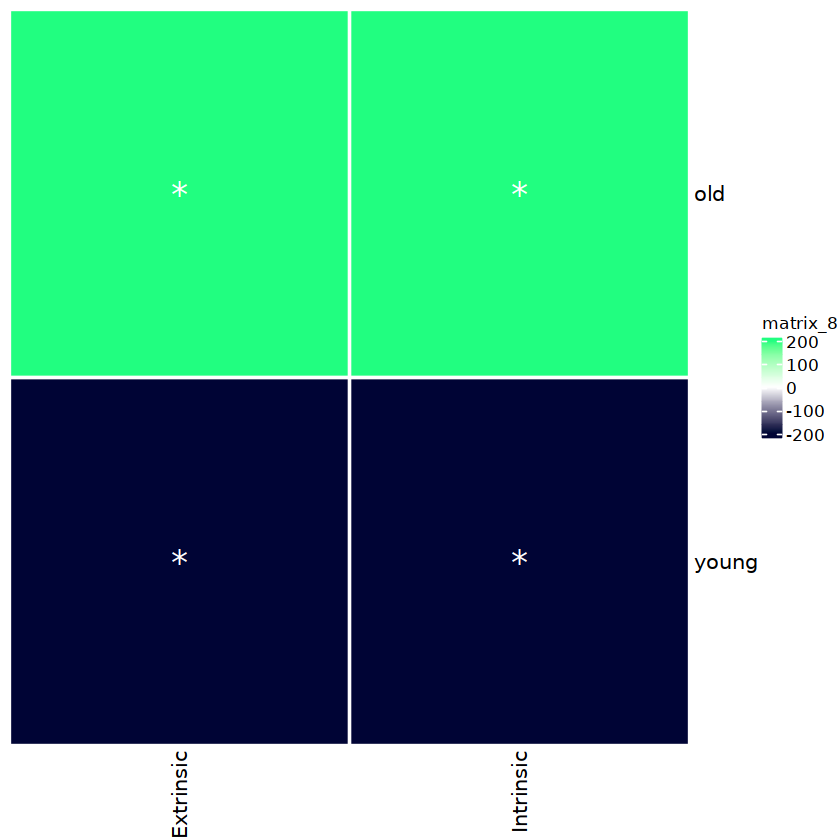

In [14]:
# Plotting -- select columns 
df <- phyper
rownames(df) <- df$status
df <- df[,-1]
df <- df[,c('geneset_pos0','geneset_neg0','geneset_pos24','geneset_neg24')]
# BH Multiple hypothesis correction 
pvals <- as.vector(as.matrix(df))  # Convert to a vector
pvals_adj <- p.adjust(pvals, method = "BH", n = length(pvals))  # Adjust all p-values at once
df <- as.data.frame(matrix(pvals_adj, nrow = nrow(df), ncol = ncol(df),
                               dimnames = list(rownames(df), colnames(df))))
# Convert pval to -log10
df = -log10(df)
df[] <- lapply(df, function(x) as.numeric(gsub("Inf", 300, x)))
# Combine pos+neg columns 
df$Intrinsic <- ifelse(df$geneset_pos24 > df$geneset_neg24, 
                    df$geneset_pos24, (-1*df$geneset_neg24))
df$Systemic <- ifelse(df$geneset_pos0 > df$geneset_neg0, 
                    df$geneset_pos0, (-1*df$geneset_neg0))          
df <- df[,c('Systemic','Intrinsic')] 

#pdf(paste0(PLOTDIR, 'Heatmap.Ruzicka_status_phyper.pdf'), width = 2, height = 2)
library(ComplexHeatmap)
Heatmap(df, cluster_rows = F, cluster_columns = F,
        col = colorRamp2(c(-200, 0, 200), c("#000435", "#FFFFFF", "#21FE80")),
        cell_fun = function(j, i, x, y, w, h, fill){
            # Draw the border for each cell
            grid.rect(x, y, w, h, gp = gpar(col = "white", lwd = 2, fill = NA))
            if(abs(df[i, j]) > 1.5) {
                grid.text('*', x, y, gp = gpar(col = "white", fontsize = 20))
            }
        })
#dev.off()

In [28]:
# Plotting -- select columns 
df <- phyper
rownames(df) <- df$status
df <- df[,-1]
df <- df[,c("geneset_dd","can_sen", "sen_init","sen_resp")]
# BH Multiple hypothesis correction 
pvals <- as.vector(as.matrix(df))  # Convert to a vector
pvals_adj <- p.adjust(pvals, method = "BH", n = length(pvals))  # Adjust all p-values at once
df <- as.data.frame(matrix(pvals_adj, nrow = nrow(df), ncol = ncol(df),
                               dimnames = list(rownames(df), colnames(df))))
# Convert pval to -log10
df = -log10(df)
df[] <- lapply(df, function(x) as.numeric(gsub("Inf", 300, x)))
df <- t(df)               

pdf(paste0(PLOTDIR, 'Heatmap.Ruzicka_status_phyper_dd_sen.pdf'), width = 3, height = 3)               
library(ComplexHeatmap)
Heatmap(df, cluster_rows = F, cluster_columns = F,
        col = c("#000435", "#FFFFFF", "#21FE80"),
        cell_fun = function(j, i, x, y, w, h, fill){
            # Draw the border for each cell
            grid.rect(x, y, w, h, gp = gpar(col = "white", lwd = 2, fill = NA))
            if(abs(df[i, j]) > 1.5) {
                grid.text('*', x, y, gp = gpar(col = "white", fontsize = 20))
            }
        })
dev.off()

pdf 
  2

In [196]:
# Overrepresentation Analysis By Celltype

# Aging Signatures 
# Senescence+DNA Damage Signatures

# Young
metadata_young <- metadata[metadata['age_status'] == 'young',]
tbl_young <- as.data.frame(table(unclass(metadata_young$Celltype)))
# Table counts
geneSet_young1 <- table(unclass(metadata_young$Celltype), metadata_young$geneset_pos0.y)
geneSet_young2 <- table(unclass(metadata_young$Celltype), metadata_young$geneset_neg0.y)
geneSet_young3 <- table(unclass(metadata_young$Celltype), metadata_young$geneset_pos24.y)
geneSet_young4 <- table(unclass(metadata_young$Celltype), metadata_young$geneset_neg24.y)

geneSet_young5 <- table(unclass(metadata_young$Celltype), metadata_young$can_sen.y)
geneSet_young6 <- table(unclass(metadata_young$Celltype), metadata_young$sen_init.y)
geneSet_young7 <- table(unclass(metadata_young$Celltype), metadata_young$sen_resp.y)
geneSet_young8 <- table(unclass(metadata_young$Celltype), metadata_young$geneset_dd.y)

tbl_young$pos0 <- rowSums(as.data.frame.matrix(geneSet_young1))
tbl_young$neg0 <- rowSums(as.data.frame.matrix(geneSet_young2))
tbl_young$pos24 <- rowSums(as.data.frame.matrix(geneSet_young3))
tbl_young$neg24 <- rowSums(as.data.frame.matrix(geneSet_young4))

tbl_young$can_sen <- rowSums(as.data.frame.matrix(geneSet_young5))
tbl_young$sen_init <- rowSums(as.data.frame.matrix(geneSet_young6))
tbl_young$sen_resp <- rowSums(as.data.frame.matrix(geneSet_young7))
tbl_young$dna_damage <- rowSums(as.data.frame.matrix(geneSet_young8))
# Renaming columns to differentiate AD
tbl1 <- tbl_young
colnames(tbl1)[2:ncol(tbl1)] <- paste0(colnames(tbl1)[2:ncol(tbl1)], '_young')

# Old
metadata_old <- metadata[metadata['age_status'] == 'old',]
tbl_old <- as.data.frame(table(unclass(metadata_old$Celltype)))

# Table counts
geneSet_old1 <- table(unclass(metadata_old$Celltype), metadata_old$geneset_pos0.y)
geneSet_old2 <- table(unclass(metadata_old$Celltype), metadata_old$geneset_neg0.y)
geneSet_old3 <- table(unclass(metadata_old$Celltype), metadata_old$geneset_pos24.y)
geneSet_old4 <- table(unclass(metadata_old$Celltype), metadata_old$geneset_neg24.y)

geneSet_old5 <- table(unclass(metadata_old$Celltype), metadata_old$can_sen.y)
geneSet_old6 <- table(unclass(metadata_old$Celltype), metadata_old$sen_init.y)
geneSet_old7 <- table(unclass(metadata_old$Celltype), metadata_old$sen_resp.y)
geneSet_old8 <- table(unclass(metadata_old$Celltype), metadata_old$geneset_dd.y)

tbl_old$pos0 <- rowSums(as.data.frame.matrix(geneSet_old1))
tbl_old$neg0 <- rowSums(as.data.frame.matrix(geneSet_old2))
tbl_old$pos24 <- rowSums(as.data.frame.matrix(geneSet_old3))
tbl_old$neg24 <- rowSums(as.data.frame.matrix(geneSet_old4))

tbl_old$can_sen <- rowSums(as.data.frame.matrix(geneSet_old5))
tbl_old$sen_init <- rowSums(as.data.frame.matrix(geneSet_old6))
tbl_old$sen_resp <- rowSums(as.data.frame.matrix(geneSet_old7))
tbl_old$dna_damage <- rowSums(as.data.frame.matrix(geneSet_old8))

# Renaming columns
tbl2 <- tbl_old
colnames(tbl2)[2:ncol(tbl2)] <- paste0(colnames(tbl2)[2:ncol(tbl2)], '_old')
# Left join tables by Var1
tbl <- left_join(tbl1, tbl2, by = 'Var1')

direction <- c('pos0', 'neg0', 'pos24', 'neg24', 'can_sen', 'sen_init','sen_resp','dna_damage')
status <- c('old','young')
celltypes <- tbl['Var1'][[1]]

f <- data.frame()
for(d in 1:length(direction)) {
    print(direction[d])
    df1 <- data.frame()
    for(s in 1:length(status)) {
        print(status[s])
        df2 <- data.frame()
        for(c in 1:length(celltypes)) {
            #print(celltypes[c])
            m_plus_n = sum(tbl[paste0('Freq_',status[s])])
            m = sum(tbl[paste0(direction[d],'_',status[s])])
            k = tbl[tbl$Var1==celltypes[c],][[paste0('Freq_',status[s])]]
            q = tbl[tbl$Var1==celltypes[c],][[paste0(direction[d],'_',status[s])]]
            phyper = phyper(q, m, m_plus_n - m, k, lower.tail = FALSE, log.p = FALSE)
            df3 = data.frame(m_plus_n, m, k, q, phyper)
            df3$celltype = celltypes[c]
            if (c > 1) df2 = rbind(df2,df3)
            if (c == 1) df2 = df3  
                    }
        df2 = df2[,c('celltype','phyper')]
        colnames(df2)[2] = paste0(direction[d],'_',status[s])
        if (s > 1) df1 = left_join(df1,df2, by = 'celltype')
        if (s == 1) df1 = df2
        }
    if (d > 1) df = left_join(df,df1, by = 'celltype')
    if (d == 1) df = df1
    }

sign_counts <- tbl
sign_phyper <- df

[1] "pos0"
[1] "old"
[1] "young"
[1] "neg0"
[1] "old"
[1] "young"
[1] "pos24"
[1] "old"
[1] "young"
[1] "neg24"
[1] "old"
[1] "young"
[1] "can_sen"
[1] "old"
[1] "young"
[1] "sen_init"
[1] "old"
[1] "young"
[1] "sen_resp"
[1] "old"
[1] "young"
[1] "dna_damage"
[1] "old"
[1] "young"


In [197]:
# Celltype Composition Underrepresentation Analysis 
# By Celltype

# Old
metadata_old <- metadata[metadata['age_status'] == 'old',]
tbl_old <- as.data.frame(table(unclass(metadata_old$Celltype)))
# Renaming columns to differentiate AD
tbl1 <- tbl_old
colnames(tbl1)[2:ncol(tbl1)] <- paste0(colnames(tbl1)[2:ncol(tbl1)], '_Old')
# Young
metadata_young <- metadata[metadata['age_status'] == 'young',]
tbl_young <- as.data.frame(table(unclass(metadata_young$Celltype)))
# Renaming columns to differentiate non-AD
tbl2 <- tbl_young
colnames(tbl2)[2:ncol(tbl2)] <- paste0(colnames(tbl2)[2:ncol(tbl2)], '_Young')
# Left join AD and non-AD tables by Var1
tbl <- left_join(tbl1, tbl2, by = 'Var1')

status <- c('Old','Young')
celltypes <- tbl['Var1'][[1]]

df1 <- data.frame()
for(s in 1:length(status)) {
    print(status[s])
    df2 <- data.frame()
    for(c in 1:length(celltypes)) {
        #print(celltypes[c])
        m_plus_n = sum(tbl$Freq_Old,tbl$Freq_Young)
        m = tbl[tbl$Var1==celltypes[c],][['Freq_Old']] + tbl[tbl$Var1==celltypes[c],][['Freq_Young']]
        k = sum(tbl[paste0('Freq_',status[s])])
        q = tbl[tbl$Var1==celltypes[c],][[paste0('Freq_',status[s])]] 
        phyper = phyper(q, m, m_plus_n - m, k, lower.tail = TRUE, log.p = FALSE)
        df3 = data.frame(m_plus_n, m, k, q, phyper)
        df3$celltype = celltypes[c]
        
        if (c > 1) df2 = rbind(df2,df3)
        if (c == 1) df2 = df3  
                }
    df2 = df2[,c('celltype','phyper')]
    colnames(df2)[2] = status[s]

    if (s > 1) df1 = left_join(df1,df2, by = 'celltype')
    if (s == 1) df1 = df2
    }
colnames(df1)[2:3] <- paste0(colnames(df1)[2:3],'_UR')

comp_counts <- tbl
comp_phyper <- df1

[1] "Old"
[1] "Young"


In [198]:
# Combine tables & Save 
counts <- left_join(comp_counts, sign_counts, by='Var1')
phyper <- left_join(comp_phyper, sign_phyper, by='celltype')
#write.csv(counts, paste0(out_dir2,'Ruzicka_celltype_counts.csv'))
#write.csv(phyper, paste0(out_dir2,'Ruzicka_celltype_phyper_uncorrected.csv'))

In [23]:
counts <- read.csv(paste0(out_dir2,'Ruzicka_celltype_counts.csv'))
phyper <- read.csv(paste0(out_dir2,'Ruzicka_celltype_phyper_uncorrected.csv'))

Warning message:
“The input is a data frame-like object, convert it to a matrix.”


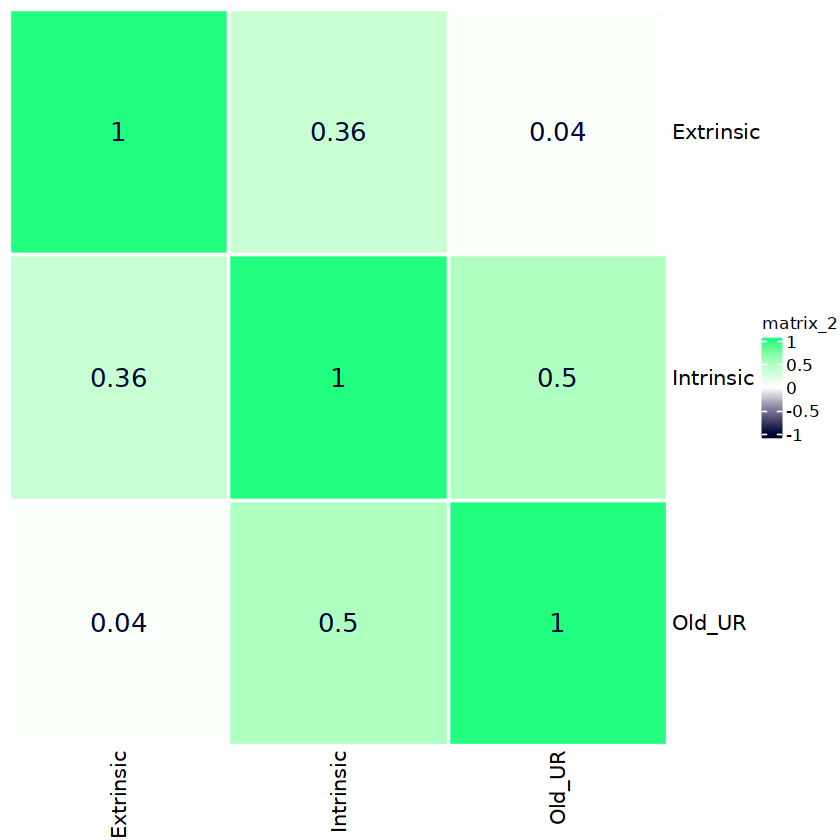

In [25]:
# Plotting -- select columns 
df <- phyper
df <- df[df$celltype != 'Ex-NRGN',]
rownames(df) <- df$celltype
df <- df[,-1]
#df <- df[, which(grepl("old", names(df), ignore.case = TRUE))]
df <- df[,c('pos0_old','neg0_old','pos24_old','neg24_old','Old_UR')]
     
# BH Multiple hypothesis correction 
pvals <- as.vector(as.matrix(df))  # Convert to a vector
pvals_adj <- p.adjust(pvals, method = "BH", n = length(pvals))  # Adjust all p-values at once
df <- as.data.frame(matrix(pvals_adj, nrow = nrow(df), ncol = ncol(df),
                               dimnames = list(rownames(df), colnames(df))))
# Convert pval to -log10
df = -log10(df)
df[] <- lapply(df, function(x) as.numeric(gsub("Inf", 300, x)))

# Combine pos+neg columns 
df$Intrinsic <- ifelse(df$pos24_old > df$neg24_old, 
                    df$pos24_old, (-1*df$neg24_old))
df$Systemic <- ifelse(df$pos0_old > df$neg0_old, 
                    df$pos0_old, (-1*df$neg0_old))
df$Old_UR <- (-1*df$Old_UR)          

df <- df[,c('Systemic','Intrinsic','Old_UR')]             
#pdf(paste0(PLOTDIR, 'Heatmap.Ruzicka_celltype_phyper_old.pdf'), width = 4, height = 5)
library(ComplexHeatmap)
Heatmap(df, cluster_rows = F, cluster_columns = F,
        col = colorRamp2(c(-200, 0, 200), c("#000435", "#FFFFFF", "#21FE80")),
        cell_fun = function(j, i, x, y, w, h, fill){
            # Draw the border for each cell
            grid.rect(x, y, w, h, gp = gpar(col = "white", lwd = 2, fill = NA))
            if(abs(df[i, j]) > 1.5) {
                grid.text('*', x, y, gp = gpar(col = "white", fontsize = 15))
            }
        })
#dev.off()

               
#pdf(paste0(PLOTDIR, 'Heatmap.Ruzicka_phyper_cor_old.pdf'), width = 3, height = 4)               
cor_matrix <- cor(df)
h1 <- Heatmap(cor_matrix, cluster_rows = F, cluster_columns = F,
              col = colorRamp2(c(-1, 0, 1), c("#000435", "#FFFFFF", "#21FE80")),
       cell_fun = function(j, i, x, y, w, h, fill){
            # Draw the border for each cell
            grid.rect(x, y, w, h, gp = gpar(col = "white", lwd = 2, fill = NA))
            grid.text(round(cor_matrix[i, j], 2), x, y, gp = gpar(fontsize = 15, col = "#000435"))
        })
draw(h1)
#dev.off()

In [35]:
# Load necessary library
#install.packages("VennDiagram")  # If not installed
library(VennDiagram)

# Define sets
Full_Overlap <- rownames(df[df$Old_UR < -1.5 & df$Systemic < -1.5 & df$Intrinsic < -1.5,])
Systemic_Overlap <- rownames(df[df$Old_UR < -1.5 & df$Systemic < -1.5,])
Intrinsic_Overlap <- rownames(df[df$Old_UR < -1.5 & df$Intrinsic < -1.5,])
Systemic_Intrinsic_Overlap <- rownames(df[df$Systemic < -1.5 & df$Intrinsic < -1.5,])
Old_UR_negative <- rownames(df[df$Old_UR < -1.5,])
Systemic <- rownames(df[df$Systemic < -1.5,])
Intrinsic <- rownames(df[df$Intrinsic < -1.5,])

pdf(paste0(PLOTDIR, 'Venn.Ruzicka_celltype_phyper_old.pdf'), width = 6, height = 6) 
# Create Venn Diagram without intersections between Systemic and Intrinsic
venn.plot <- draw.triple.venn(
  area1 = length(Systemic),  # Systemic
  area2 = length(Old_UR_negative),    # Old_UR negative
  area3 = length(Intrinsic),  # Intrinsic
  n12 = length(Systemic_Overlap), # Only Systemic & Old_UR Negative overlap
  n13 = length(Systemic_Intrinsic_Overlap),  
  n23 = length(Intrinsic_Overlap),  # Only Intrinsic & Old_UR Negative overlap
  n123 = length(Full_Overlap),  # intersection between all three
  category = c("Negative Systemic", "Age Depletion", "Negative Intrinsic"),
  fill = c("#FFFFFF","#000435", "#21FE80"),
  alpha = 0.5,
  cat.col = c("black", "black", "black"),
  cex = 1.2,
  cat.cex = 1.5
)
# Add text labels for cell types inside each section
grid.text(paste(Systemic[!Systemic %in% c(Systemic_Intrinsic_Overlap,Systemic_Overlap)], collapse="\n"), x = 0.2, y = 0.3, gp=gpar(fontsize=15))
grid.text(paste(Intrinsic[!Intrinsic %in% c(Systemic_Intrinsic_Overlap,Intrinsic_Overlap)], collapse="\n"), x = 0.5, y = 0.8, gp=gpar(fontsize=15))
grid.text(paste(Old_UR_negative[!Old_UR_negative %in% c(Intrinsic_Overlap, Systemic_Overlap)], collapse="\n"), x = 0.8, y = 0.3, gp=gpar(fontsize=15))
#grid.text(paste(Systemic_Overlap, collapse="\n"), x = 0.5, y = 0.5, gp=gpar(fontsize=15))
grid.text(paste(Intrinsic_Overlap[!Intrinsic_Overlap %in% Full_Overlap], collapse="\n"), x = 0.7, y = 0.5, gp=gpar(fontsize=15))
grid.text(paste(Systemic_Intrinsic_Overlap[!Systemic_Intrinsic_Overlap %in% Full_Overlap], collapse="\n"), x = 0.3, y = 0.5, gp=gpar(fontsize=15))
grid.text(paste(Full_Overlap, collapse="\n"), x = 0.5, y = 0.5, gp=gpar(fontsize=15))
# Display plot
grid.draw(venn.plot)
dev.off()

pdf 
  2

In [47]:
# Plotting -- select columns 
df <- phyper
df <- df[df$celltype != 'Ex-NRGN',]
rownames(df) <- df$celltype
df <- df[,-1]
df <- df[, which(grepl("old", names(df), ignore.case = TRUE))]
#df <- df[,c('can_sen_old', 'sen_init_old','sen_resp_old','dna_damage_old','Old_UR')]     
# BH Multiple hypothesis correction 
pvals <- as.vector(as.matrix(df))  # Convert to a vector
pvals_adj <- p.adjust(pvals, method = "BH", n = length(pvals))  # Adjust all p-values at once
df <- as.data.frame(matrix(pvals_adj, nrow = nrow(df), ncol = ncol(df),
                               dimnames = list(rownames(df), colnames(df))))
# Convert pval to -log10
df = -log10(df)
df[] <- lapply(df, function(x) as.numeric(gsub("Inf", 300, x)))
            
pdf(paste0(PLOTDIR, 'Heatmap.Ruzicka_celltype_phyper_dd_sen_old.pdf'), width = 5, height = 5)
library(ComplexHeatmap)
Heatmap(df, cluster_rows = F, cluster_columns = F,
        col = c("#000435", "#FFFFFF", "#21FE80"),
        cell_fun = function(j, i, x, y, w, h, fill){
            # Draw the border for each cell
            grid.rect(x, y, w, h, gp = gpar(col = "white", lwd = 2, fill = NA))
            if(abs(df[i, j]) > 1.5) {
                grid.text('*', x, y, gp = gpar(col = "white", fontsize = 15))
            }
        })
dev.off()

pdf(paste0(PLOTDIR, 'Heatmap.Ruzicka_phyper_cor_dd_sen_old.pdf'), width = 8, height = 8)               
cor_matrix <- cor(df)
h1 <- Heatmap(cor_matrix, cluster_rows = T, cluster_columns = T,
              col = colorRamp2(c(-1, 0, 1), c("#000435", "#FFFFFF", "#21FE80")),
       cell_fun = function(j, i, x, y, w, h, fill){
            # Draw the border for each cell
            grid.rect(x, y, w, h, gp = gpar(col = "white", lwd = 2, fill = NA))
            grid.text(round(cor_matrix[i, j], 2), x, y, gp = gpar(fontsize = 15, col = "#000435"))
        })
draw(h1)
dev.off()              

Warning message:
“The input is a data frame-like object, convert it to a matrix.”


pdf 
  2

pdf 
  2

In [2]:
# Correlations

metadata <- read.csv(paste0(data_dir2,"Ruzicka_metadata_AUCell_all_scores.csv"))
df <- metadata[,c(5,37:69)]

pred_age <- read.csv(paste0(out_dir2,'24_10_02_model_M24_predictions_gene_filtering_mean_age_corrected_pred_age.csv'),row.names = 1)
pred_age <- pred_age[,which(names(pred_age) %in% c('Id','predicted_age_0','predicted_age_24'))]  

df <- left_join(df, pred_age, by = 'Id')
df1 <- df[,c('geneset_sc0','geneset_sc24', 'geneset_dd.x',
                'can_sen.x','sen_init.x','sen_resp.x','cellage.x',
                'predicted_age_0','predicted_age_24')]

cor_matrix <- cor(na.omit(df1))
h1 <- Heatmap(cor_matrix, col = colorRamp2(c(-1, 0, 1), c("#000435", "#FFFFFF", "#21FE80")),
              cluster_rows = T, cluster_columns = T,
             cell_fun = function(j, i, x, y, w, h, fill){
            # Draw the border for each cell
            grid.rect(x, y, w, h, gp = gpar(col = "white", lwd = 2, fill = NA))
            grid.text(round(cor_matrix[i, j], 2), x, y, gp = gpar(fontsize = 15, col = "#000435"))
        })
draw(h1)

Id,geneset_pos0_cr.x,geneset_neg0_cr.x,geneset_pos9_cr.x,geneset_neg9_cr.x,geneset_pos0.x,geneset_neg0.x,geneset_pos24.x,geneset_neg24.x,geneset_dd.x,⋯,can_sen.y,sen_init.y,sen_resp.y,cellage.y,predicted_age_0,predicted_age_24,calib_res_0,predicted_res_1,predicted_res_9,calib_res_9
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AAACCCACAATGAACA-1,0.2012651,0.1731228,0.17145132,0.18998273,0.1239479,0.13580417,0.13941695,0.10532080,0.02609893,⋯,can_sen,NA,sen_resp,NA,62.09686,64.57194,-4.98146896,-1.2699900,-0.053190639,-0.07358969
AAACCCAGTATAGCTC-1,0.1740611,0.0884530,0.21528730,0.11427749,0.1623153,0.11356204,0.12815992,0.06905479,0.03191295,⋯,NA,NA,sen_resp,NA,67.54344,72.29881,-6.27820831,-0.3360632,-0.419704638,-0.36663362
AAACCCATCATGAAAG-1,0.2559384,0.2308578,0.24041226,0.17575459,0.1554059,0.12367210,0.12308898,0.08859325,0.02904960,⋯,NA,sen_init,NA,NA,82.91780,78.21130,4.14961179,2.5464436,0.161889611,0.09869754
AAACCCATCTGGCCGA-1,0.1485823,0.2163418,0.09722652,0.12270746,0.1302847,0.11699333,0.10646714,0.10077128,0.03796067,⋯,NA,NA,sen_resp,cellage,73.34978,71.00984,-0.47187161,0.0425287,-0.143874746,-0.09080373
AAACGAAGTGGTCTGC-1,0.1597735,0.1338926,0.13203875,0.09659511,0.1430111,0.10066405,0.12482199,0.08085752,0.04364116,⋯,can_sen,sen_init,sen_resp,NA,79.68516,72.94847,5.86351085,1.9416533,0.014176594,0.06724761
AAACGAATCACATTGG-1,0.2030345,0.2287606,0.20604238,0.13438605,0.1445482,0.15107649,0.12082853,0.09676555,0.02439889,⋯,can_sen,NA,NA,cellage,70.07417,65.10681,2.99583936,0.7632599,0.214392719,0.19399366
AAACGAATCTACTTCA-1,0.2370062,0.1738630,0.19706286,0.10946624,0.1700385,0.11684015,0.14327479,0.06540138,0.03081127,⋯,NA,NA,NA,NA,88.56944,80.36600,9.80124845,2.4809574,-0.035786592,-0.09897866
AAACGCTAGACGCATG-1,0.2076790,0.1996052,0.22254169,0.11867752,0.1592938,0.13909760,0.13625233,0.08474836,0.02105274,⋯,can_sen,NA,NA,NA,72.40314,67.61461,5.32481295,1.2712252,0.363077534,0.34267848
AAACGCTAGCGACCCT-1,0.1897200,0.1921211,0.25930022,0.11481207,0.1385731,0.12972282,0.12968195,0.06287386,0.02901364,⋯,NA,sen_init,NA,NA,79.79817,73.46845,5.97651980,1.5456904,0.191852762,0.24492378
